In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests
from datetime import datetime, timedelta

In [64]:
#Load Data
transactions = pd.read_csv('walmart_transactions.csv')
stores = pd.read_csv('store_locations.csv')
products = pd.read_csv('product_catalog.csv')
dist_centers = pd.read_csv('distribution_centers.csv')

#q5
conn_sqlite = sqlite3.connect('inventory_and_sales.db')
daily_sales = pd.read_sql_query("SELECT * FROM daily_sales_summary", conn_sqlite)
inventory_levels = pd.read_sql_query("SELECT * FROM inventory_levels", conn_sqlite)
conn_sqlite.close()

In [65]:
for df, name in zip([transactions, stores, products, dist_centers, daily_sales, inventory_levels],
                    ['transactions','stores','products','dist_centers','daily_sales','inventory_levels']):
    print(f"{name} shape:", df.shape)
    display(df.head())
    print(df.isnull().sum())
    print('-'*40)

transactions shape: (25562, 8)


,transaction_id,store_id,timestamp,sku,product_name,category,quantity,unit_price
0,TXN012636,FL-710,2024-09-13T09:48:13,PNUTBTR-16,PEANUT BUTTER,Grocery,1,3.15
1,TXN000759,fl-412,2024-09-02 20:30:20,CNSOUP-01,CANNED SOUP,GROCERY,1,2.02
2,TXN003338,FL-105,2024-09-06 10:06:00,TOILETPAPER12,Toilet Paper 12-Roll,Household Essentials,2,10.47
3,TXN025020,FL-330,2024-09-30 06:29:08,ROKU-STD,Roku Streaming Stick,ELECTRONICS,1,28.59
4,TXN015797,FL-302,2024-09-15 15:59:42,BEER-24,Light Beer 24pk,Alcoholic Beverages,3,18.82


transaction_id      0
store_id            0
timestamp         886
sku                 0
product_name        0
category            0
quantity            0
unit_price          0
dtype: int64
----------------------------------------
stores shape: (14, 8)


,store_id,store_name,city,state,zip_code,latitude,longitude,region
0,FL-239,Walmart Supercenter Orlando,Orlando,FL,32801,28.5383,-81.3792,Central
1,FL-105,Walmart Supercenter Tampa,Tampa,FL,33602,27.9506,-82.4572,West
2,FL-330,Walmart Supercenter Miami,Miami,FL,33101,25.7617,-80.1918,South
3,FL-412,Walmart Supercenter Jacksonville,Jacksonville,FL,32099,30.3322,-81.6557,North
4,FL-287,Walmart Neighborhood Market Kissimmee,Kissimmee,Florida,34741,28.2920,-81.4076,Central


store_id      0
store_name    0
city          0
state         0
zip_code      0
latitude      1
longitude     1
region        0
dtype: int64
----------------------------------------
products shape: (45, 7)


...

dc_id                     0
dc_name                   0
city                      0
state                     0
avg_daily_shipments       0
surge_capacity            0
distance_to_orlando_mi    0
cost_per_shipment         1
dtype: int64
----------------------------------------
daily_sales shape: (3600, 5)


,date,store_id,category,total_units,total_revenue
0,2024-09-01,FL-239,Emergency,90.0,1582.55
1,2024-09-01,FL-239,Breakfast,57.0,356.99
2,2024-09-01,FL-239,Alcohol,41.0,246.65
3,2024-09-01,FL-239,Entertainment,53.0,916.56
4,2024-09-01,FL-239,Grocery,69.0,339.30


date             0
store_id         0
category         0
total_units      0
total_revenue    0
dtype: int64
----------------------------------------
inventory_levels shape: (4320, 6)


,date,store_id,sku,units_on_hand,units_on_order,reorder_point
0,2024-09-01,FL-239,CHIPS-VP,112,5.0,31
1,2024-09-01,FL-239,PAPERTOWEL6,106,46.0,36
2,2024-09-01,FL-239,PT-12,62,36.0,30
3,2024-09-01,FL-239,PORTCHARGER,185,62.0,40
4,2024-09-01,FL-239,BFORM-01,88,1.0,35


date                0
store_id            0
sku                 0
units_on_hand       0
units_on_order    626
reorder_point       0
dtype: int64
----------------------------------------


In [49]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 28.5383,   # Orlando
    "longitude": -81.3792,
    "start_date": "2024-09-01",
    "end_date": "2024-09-30",
    "hourly": "temperature_2m,precipitation,wind_speed_10m",
    "timezone": "America/New_York"
}

response = requests.get(weather_url, params=params)
weather_json = response.json()

weather_df = pd.DataFrame(weather_json['hourly'])
weather_df['datetime'] = pd.to_datetime(weather_df['time'])
weather_df.drop(columns=['time'], inplace=True)

# Aggregate to daily
weather_daily = weather_df.groupby(weather_df['datetime'].dt.date).agg({
    'temperature_2m':'mean',
    'precipitation':'sum',
    'wind_speed_10m':'mean'
}).reset_index().rename(columns={'datetime':'day'})
weather_daily['day'] = pd.to_datetime(weather_daily['day'])


Question 1:

In [82]:
#DATA CLEANING & CALCULATIONS

#Standardize column names:
transactions.columns = (
    transactions.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

#Remove dupes
transactions = transactions.drop_duplicates(subset="transaction_id")

#convert timestamp column to datetime
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], errors="coerce")

# remove rows where timestamp failed to parse
transactions = transactions.dropna(subset=["timestamp"])

# clean category column
transactions["category"] = (
    transactions["category"]
    .astype(str)
    .str.strip()
    .str.title()
)

# convert quantity to numeric
transactions["quantity"] = pd.to_numeric(transactions["quantity"], errors="coerce")

# remove missing quantities
transactions = transactions.dropna(subset=["quantity"])

# fix negative values
transactions.loc[transactions["quantity"] < 0, "quantity"] = 0

# extract date from timestamp
transactions["date"] = transactions["timestamp"].dt.date

# convert back to datetime for plotting
transactions["date"] = pd.to_datetime(transactions["date"])

#Group sales by category and day
daily_category_sales = (transactions.groupby(["date", "category"])["quantity"].sum().reset_index())

#define hurricane periods: sept. 15
landfall = pd.Timestamp("2024-09-15")

# 7 days before hurricane
surge_start = landfall - pd.Timedelta(days=7)

# baseline week before that
baseline_start = surge_start - pd.Timedelta(days=7)     #

#calculates baseline sales
baseline = (daily_category_sales[
        (daily_category_sales["date"] >= baseline_start) &
        (daily_category_sales["date"] < surge_start)].groupby("category")["quantity"]
    .sum()
)

#calculate surge sales
surge = (daily_category_sales[
        (daily_category_sales["date"] >= surge_start) &
        (daily_category_sales["date"] <= landfall)].groupby("category")["quantity"]
    .sum()
)

#compute percent increase
comparison = pd.DataFrame({"baseline_sales": baseline,"surge_sales": surge}).dropna()

comparison["percent_increase"] = (
    (comparison["surge_sales"] - comparison["baseline_sales"])
    / comparison["baseline_sales"]
) * 100

#finds top 5 surge categories
top5 = comparison.sort_values(
    "percent_increase",
    ascending=False
).head(5)

print(top5)

                     baseline_sales  surge_sales  percent_increase
category                                                          
Household                        23           78        239.130435
Alcoholic Beverages              16           48        200.000000
Emergency Supplies               76          222        192.105263
Breakfast Foods                  78          226        189.743590
Emergency                       115          322        180.000000


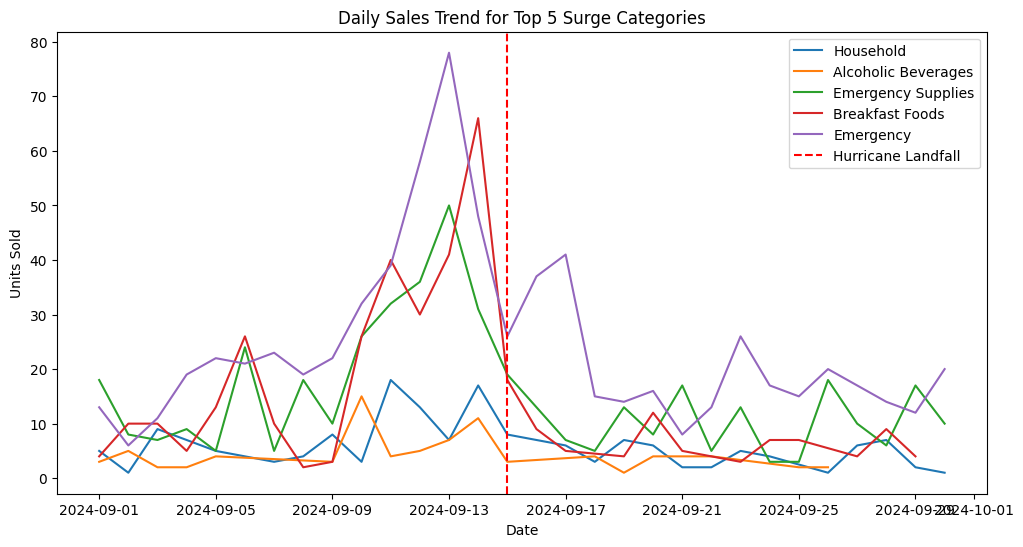

In [79]:
#Visualization:
top_categories = top5.index.tolist()

plot_data = daily_category_sales[daily_category_sales["category"].isin(top_categories)]

plt.figure(figsize=(12,6))
for cat in top_categories:
    subset = plot_data[plot_data["category"] == cat]
    plt.plot(subset["date"], subset["quantity"], label=cat)

plt.axvline(landfall, color="red", linestyle="--", label="Hurricane Landfall")
plt.title("Daily Sales Trend for Top 5 Surge Categories")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

To identify which product categories experienced the largest surge before the hurricane, I compared category sales during the seven days before hurricane landfall to a baseline period one week earlier. After cleaning the transaction dataset by removing duplicates, fixing timestamps, standardizing category names, and correcting quantity values, I aggregated daily sales by category. I then calculated the percent increase in total units sold between the baseline and surge periods. The results show that several categories experienced significant increases in demand, with breakfast foods, emergency items, entertainment products, emergency supplies, and alcoholic beverages showing the largest growth. Breakfast products had the highest increase, suggesting that consumers were stocking up on easy-to-store food before the storm.

The visualization of daily sales trends shows that purchases begin rising several days before the hurricane and peak shortly before landfall. Most categories reach their highest sales around September 13–14, followed by a drop in sales after the storm passes. This pattern indicates that the surge in demand is closely tied to hurricane preparation behavior, as consumers buy both essential supplies and comfort items in anticipation of the storm.